# Full Bayesian Operator Inference: FitzHugh-Nagumo

**Workflow:**
1. Generate training data and fit POD basis
2. Grid search for prior operator
3. Fit GP hyperparameters
4. Run Bayesian inference (SVI/MCMC)
5. Evaluate and visualize results

## 1. Setup and Configuration

In [46]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import jax
import jax.numpy as jnp
import opinf
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist

from core import (
    generate_trajectory,
    JaxCompatibleModel,
    grid_search_prior_operator,
    fit_gp_hyperparameters_mle,
    compute_gp_derivatives,
    build_bayesian_opinf_model,
    run_svi,
    run_mcmc,
    generate_rom_predictions,
    plot_deterministic_rom_solves,
    plot_gp_fit,
    plot_operator_derivative_fit,
    plot_full_order_error,
    save_paper_figure,
    Plotter,
    run_diagnostics,
    diagnose_stability,
    DataScaler,
)
import config
from config import Basis, ReducedOrderModel
from fitz_plotter import FitzPlotter

numpyro.set_platform('cpu')
numpyro.set_host_device_count(4)

# Reproducibility
np.random.seed(42)
rng_key = jax.random.PRNGKey(42)

In [47]:
# === EXPERIMENT CONFIGURATION ===
OPERATORS = "cAHBN"       # OpInf operator structure (with inputs)
NUM_MODES = 3             # POD modes to retain

# Data generation settings
TRAINING_SPAN = (0, 3.0)  # Subset of time domain for training
PREDICTION_SPAN = (0, 5.0) # Full time domain for ROM evaluation
NUM_SAMPLES = 250          # Number of training samples
NOISE_LEVEL = 0.03        # Noise level for training data
NUM_EVAL_POINTS = None     # Set to None for no densification
LS_BOUNDS = (0.01, 1.5)   # Lengthscale bounds for GP MLE (None for unconstrained)
GRID_SEARCH_RANGE = np.logspace(-6, 4, 81)  # Regularization values for prior operator search
IVP_METHOD = "Radau"   # ODE solver for stability testing (implicit for stiff FN system)

# Data scaling
USE_SCALED_DATA = True    # Standardize POD coefficients for GP fitting

# Inference settings
RUN_SVI = True
RUN_MCMC = True           # More expensive, optional
USE_SVI_FOR_MCMC_INIT = True  # Initialize MCMC from SVI result
USE_SHIFTED_PRIOR_FOR_MCMC = True  # Rebuild model with prior shifted to SVI posterior for MCMC
USE_DETERMINISTIC_PRIOR = True  # Use deterministic OpInf solve as prior mean for SVI
GUIDE = numpyro.infer.autoguide.AutoDelta  # Guide for SVI
# GUIDE = numpyro.infer.autoguide.AutoNormal
VERBOSE = True             # Show progress bars (set False for papermill runs)

# Hyperparameters
GAMMA = 1e0      # Operator prior scale (multiplied by |O_ij| when relative_gamma=True)
GAMMA2 = 1e0     # ODE constraint slack (added to derivative covariance diagonal)
RELATIVE_GAMMA2 = False   # Scale gamma2 per mode by derivative variance (larger derivs get more slack)
GAMMA3 = 1e-1    # Operator prior variance for MCMC (if different from SVI)
GAMMA4 = 1e-1    # ODE constraint stiffness for MCMC (if different from SVI)

# Paper figure generation
SAVE_PAPER_FIGURES = False         # Set True to save publication figures
PAPER_SCENARIO = "dense_low"      # Scenario tag: dense_low, dense_high, sparse_med, etc.
PAPER_FIGURES_DIR = "../../GP-Bayes-Refactor/figures/manu"

## 2. Generate Training Data

In [48]:
# Generate training data using the standard pipeline
(fom, time_domain_full, true_states, time_sampled, snapshots_sampled) = \
    generate_trajectory(config, np.linspace(*PREDICTION_SPAN, 801), TRAINING_SPAN, NUM_SAMPLES, NOISE_LEVEL)

# Input function
input_func = ReducedOrderModel.input_func
inputs_sampled = np.array(input_func(time_sampled))

print(f"Full time domain: {time_domain_full.shape}")
print(f"True states: {true_states.shape}")
print(f"Sampled times: {time_sampled.shape}")
print(f"Sampled snapshots: {snapshots_sampled.shape}")
print(f"Training span: [{TRAINING_SPAN[0]:.4f}, {TRAINING_SPAN[1]:.4f}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]:.4f}, {PREDICTION_SPAN[1]:.4f}]")

generating training data...done in 0.26 s.
Full time domain: (801,)
True states: (1024, 801)
Sampled times: (250,)
Sampled snapshots: (1024, 250)
Training span: [0.0000, 3.0000]
Prediction span: [0.0000, 5.0000]


In [49]:
# Fit POD basis
basis = Basis(num_vectors=NUM_MODES)
basis.fit(snapshots_sampled)

snapshots_comp_sampled = basis.compress(snapshots_sampled)
full_states_compressed = basis.compress(true_states)
print(f"Compressed shape: {snapshots_comp_sampled.shape}")
print(f"Cumulative energy: {basis.cumulative_energy:.4%}")

Compressed shape: (3, 250)
Cumulative energy: 99.7357%


In [50]:
# Set up evaluation time domains for plotting
NUM_REGRESSION_POINTS = 150
time_domain_eval_training = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], NUM_REGRESSION_POINTS)
time_domain_eval_prediction = np.linspace(PREDICTION_SPAN[0], PREDICTION_SPAN[1], NUM_REGRESSION_POINTS)

print(f"Training samples: {time_sampled.shape[0]}")
print(f"Eval training domain: [{time_domain_eval_training[0]:.4f}, {time_domain_eval_training[-1]:.4f}] ({len(time_domain_eval_training)} pts)")
print(f"Eval prediction domain: [{time_domain_eval_prediction[0]:.4f}, {time_domain_eval_prediction[-1]:.4f}] ({len(time_domain_eval_prediction)} pts)")

Training samples: 250
Eval training domain: [0.0000, 3.0000] (150 pts)
Eval prediction domain: [0.0000, 5.0000] (150 pts)


## 3a. Data Scaling (Optional)

In [51]:
# Optionally scale data for GP fitting
if USE_SCALED_DATA:
    data_scaler = DataScaler(num_modes=NUM_MODES)
    data_scaler.fit(snapshots_comp_sampled)
    training_data = data_scaler.transform(snapshots_comp_sampled)
    print(f"Scaling enabled: {data_scaler}")
else:
    data_scaler = None
    training_data = snapshots_comp_sampled
    print("Scaling disabled: using raw POD coefficients")

Scaling enabled: DataScaler(num_modes=3, fitted=True, mean_range=[4.157e-01, 1.482e+01], std_range=[1.358e+00, 1.180e+01])


## 3. Grid Search for Prior Operator

In [52]:
# Find best deterministic operator via regularization grid search
result = grid_search_prior_operator(
    basis=basis,
    time_domain_sampled=time_sampled,
    snapshots_sampled=snapshots_sampled,
    snapshots_compressed=snapshots_comp_sampled,
    operators=OPERATORS,
    inputs=inputs_sampled.T if inputs_sampled.ndim > 1 else inputs_sampled[:, None].T,
    input_func=input_func,
    verbose=VERBOSE,
    reg_values=GRID_SEARCH_RANGE,
    ivp_method=IVP_METHOD,
)

prior_operator = result.operator
rom = result.rom
print(f"\nPrior operator shape: {prior_operator.shape}")

Grid search: testing 81 regularization values...
  reg=1.0e-06: STABLE, error=0.694242
  reg=1.3e-06: STABLE, error=0.694242
  reg=1.8e-06: STABLE, error=0.694242
  reg=2.4e-06: STABLE, error=0.694242
  reg=3.2e-06: STABLE, error=0.694242
  reg=4.2e-06: STABLE, error=0.694242
  reg=5.6e-06: STABLE, error=0.694242
  reg=7.5e-06: STABLE, error=0.694242
  reg=1.0e-05: STABLE, error=0.694242
  reg=1.3e-05: STABLE, error=0.694242
  reg=1.8e-05: STABLE, error=0.694242
  reg=2.4e-05: STABLE, error=0.694242
  reg=3.2e-05: STABLE, error=0.694242
  reg=4.2e-05: STABLE, error=0.694242
  reg=5.6e-05: STABLE, error=0.694242
  reg=7.5e-05: STABLE, error=0.694242
  reg=1.0e-04: STABLE, error=0.694242
  reg=1.3e-04: STABLE, error=0.694242
  reg=1.8e-04: STABLE, error=0.694242
  reg=2.4e-04: STABLE, error=0.694242
  reg=3.2e-04: STABLE, error=0.694242
  reg=4.2e-04: STABLE, error=0.694242
  reg=5.6e-04: STABLE, error=0.694242
  reg=7.5e-04: STABLE, error=0.694242
  reg=1.0e-03: STABLE, error=0.694241
 

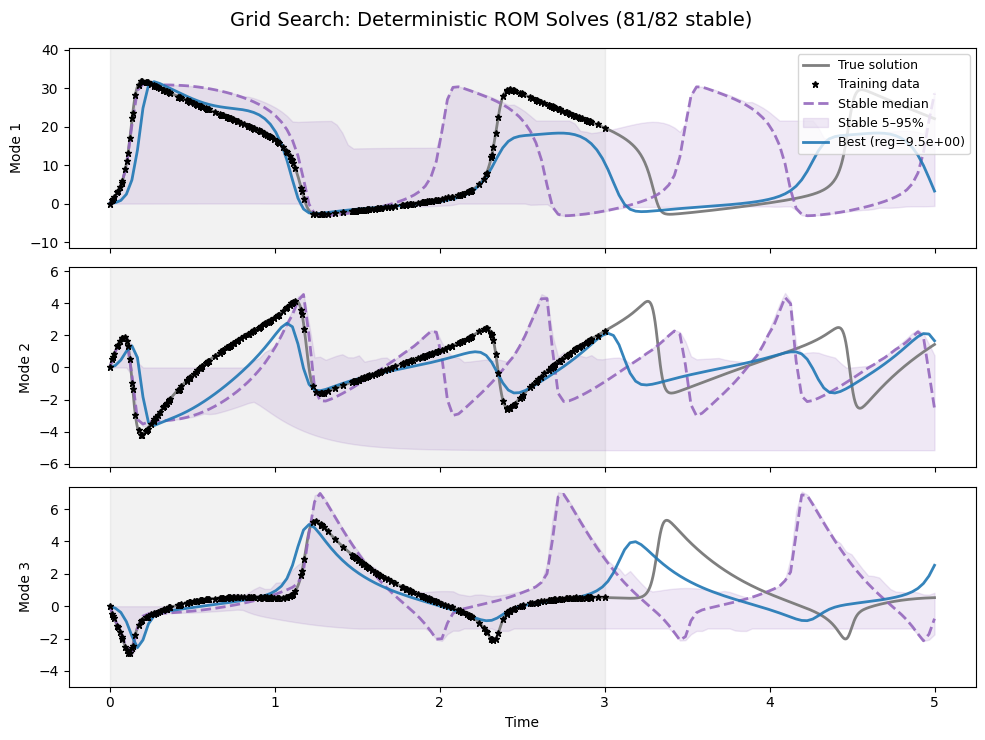

In [53]:
# Plot all stable deterministic ROM solves from grid search
from fitz_plotter import plot_fitz_grid_search

fig, axes = plot_fitz_grid_search(
    grid_search_result=result,
    snapshots_compressed=snapshots_comp_sampled,
    time_sampled=time_sampled,
    time_eval_training=time_domain_eval_training,
    time_eval_prediction=time_domain_eval_prediction,
    num_modes=NUM_MODES,
    input_func=input_func,
    time_full=time_domain_full,
    true_states_compressed=full_states_compressed,
    training_span=TRAINING_SPAN,
    ivp_method=IVP_METHOD,
)
plt.show()

## 4. Fit GP Hyperparameters

In [54]:
# Start time of the full algorithm
import time

start_time = time.time()
total_plot_time = 0

In [55]:
# Fit GP for each mode via MLE (on scaled data if enabled)
Ls, Vs, Ns, gp_models = fit_gp_hyperparameters_mle(
    time_domain=time_sampled,
    snapshots=training_data,
    verbose=VERBOSE,
    lengthscale_bounds=LS_BOUNDS,
)

Fitting GP hyperparameters via MLE...
  Lengthscale bounds: [0.0100, 1.5000]
  L=0.0561, V=0.5032, N=0.000013
  Mode 0: L=0.0561, V=0.5032, N=0.000013
  L=0.0494, V=0.5904, N=0.000103
  Mode 1: L=0.0494, V=0.5904, N=0.000103
  L=0.0485, V=0.6465, N=0.000040
  Mode 2: L=0.0485, V=0.6465, N=0.000040


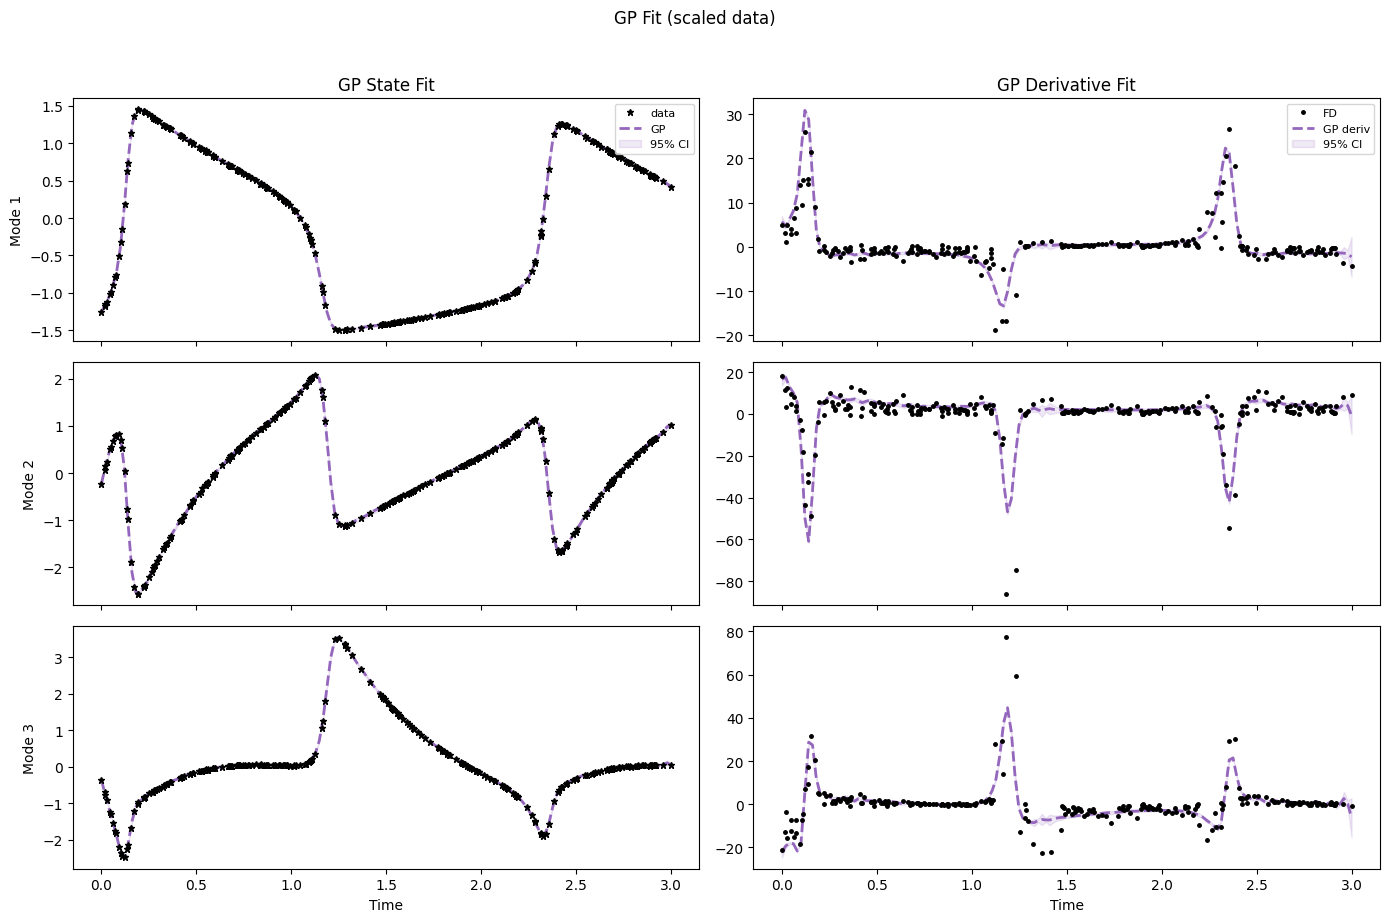

In [56]:
# Visualize GP fit quality (states and derivatives)
# Note: GP models were fitted on training_data (scaled if USE_SCALED_DATA)
_plot_t0 = time.time()
fig, axes = plot_gp_fit(
    gp_models=gp_models,
    snapshots_compressed=training_data,
    time_sampled=time_sampled,
    time_eval=time_domain_eval_training,
    lengthscales=Ls,
    variances=Vs,
    plot_derivatives=True,
)
plt.suptitle(f"GP Fit ({'scaled' if USE_SCALED_DATA else 'unscaled'} data)", y=1.02)
plt.show()
total_plot_time += time.time() - _plot_t0

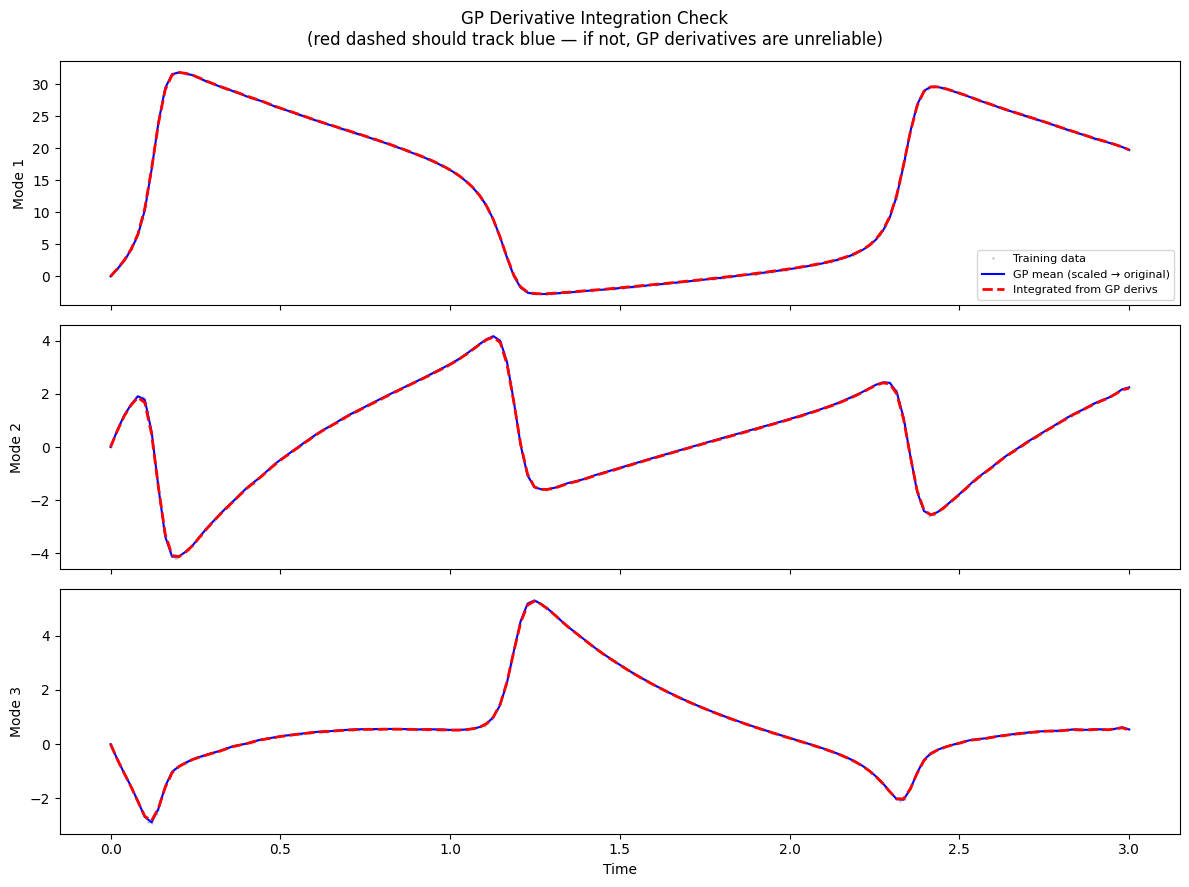

  Mode 1: relative L2 integration error = 0.0034
  Mode 2: relative L2 integration error = 0.0139
  Mode 3: relative L2 integration error = 0.0077


In [57]:
# Sanity check: integrate GP derivatives to see if they reconstruct the trajectory.
# If the integrated trajectory diverges from the data, the GP derivatives are unreliable
# and downstream Bayesian inference will struggle regardless of hyperparameters.
from scipy.integrate import cumulative_trapezoid

t_dense = time_domain_eval_training

# GP mean predictions at dense evaluation points
gp_means = np.array([
    gp_models[i].predict(t_dense[:, None], return_std=False)
    for i in range(NUM_MODES)
])

# GP derivative means at the same points
mu_z_check, _ = compute_gp_derivatives(
    Ls, Vs, time_sampled, t_dense, training_data, Ns=Ns
)

# Integrate derivatives from the initial condition: q(t) = q(0) + ∫₀ᵗ μ_z(s) ds
q_integrated = np.zeros_like(gp_means)
for i in range(NUM_MODES):
    q0 = gp_means[i, 0]  # initial condition from GP mean
    q_integrated[i, 1:] = q0 + cumulative_trapezoid(np.array(mu_z_check[i]), t_dense)
    q_integrated[i, 0] = q0

# Convert to original space for comparison if using scaled data
if USE_SCALED_DATA:
    gp_means_orig = data_scaler.inverse_transform(gp_means)
    q_integrated_orig = data_scaler.inverse_transform(q_integrated)
    data_label = "GP mean (scaled → original)"
else:
    gp_means_orig = gp_means
    q_integrated_orig = q_integrated
    data_label = "GP mean"

fig, axes = plt.subplots(NUM_MODES, 1, figsize=(12, 3 * NUM_MODES), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_sampled, snapshots_comp_sampled[i], '.', color='gray',
            alpha=0.3, markersize=2, label='Training data')
    ax.plot(t_dense, gp_means_orig[i], 'b-', lw=1.5, label=data_label)
    ax.plot(t_dense, q_integrated_orig[i], 'r--', lw=2, label='Integrated from GP derivs')
    ax.set_ylabel(f"Mode {i+1}")
    if i == 0:
        ax.legend(fontsize=8)

axes[-1].set_xlabel("Time")
fig.suptitle("GP Derivative Integration Check\n"
             "(red dashed should track blue — if not, GP derivatives are unreliable)",
             fontsize=12)
plt.tight_layout()
plt.show()

# Quantitative check: relative L2 error per mode
for i in range(NUM_MODES):
    l2_err = np.linalg.norm(q_integrated_orig[i] - gp_means_orig[i]) / np.linalg.norm(gp_means_orig[i])
    print(f"  Mode {i+1}: relative L2 integration error = {l2_err:.4f}")


GP-derivative prior: best reg = 3.16e-03, relative residual = 0.0423
Operator shape: (3, 14)
Grid search prior residual: 0.3186

>>> prior_operator overridden with GP-derivative prior


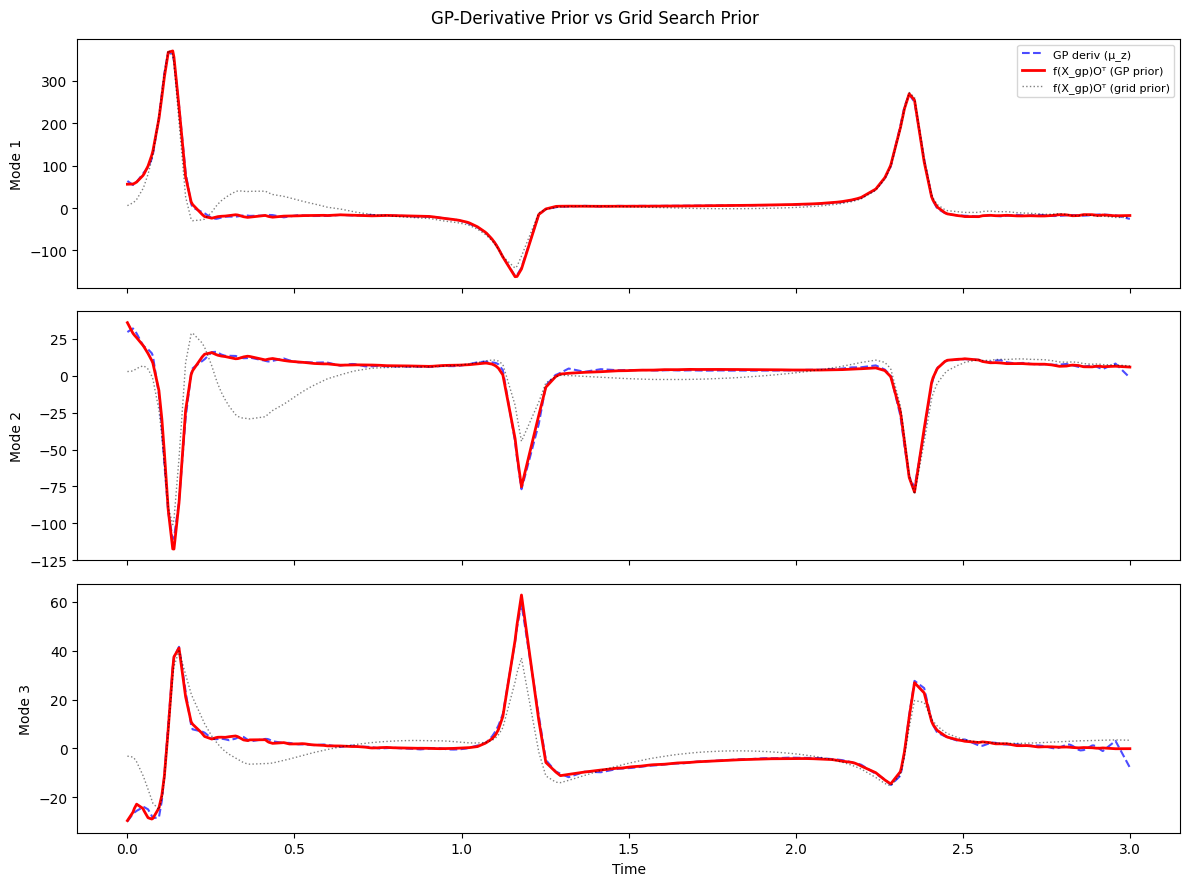

In [58]:
# === EXPERIMENTAL: GP-derivative-based prior operator ===
# Instead of using the grid search prior (which uses noisy finite differences),
# compute the prior operator by solving OpInf least-squares with GP-smoothed
# states and derivatives. This gives a much better starting point for SVI.
# DELETE THIS CELL if it doesn't help.

USE_GP_PRIOR = True  # Toggle to compare with grid search prior

if USE_GP_PRIOR:
    from core.bayesian_opinf import compute_gp_derivatives

    # Get GP states and derivatives at training times
    gp_states = np.array([
        gp_models[i].predict(time_sampled[:, None], return_std=False)
        for i in range(NUM_MODES)
    ])  # (r, n_train)

    mu_z_prior, _ = compute_gp_derivatives(
        Ls, Vs, time_sampled, time_sampled, training_data, Ns=Ns
    )  # (r, n_train)

    # If using scaled data, convert GP states back to original space for data matrix
    if USE_SCALED_DATA and data_scaler is not None:
        gp_states_orig = data_scaler.inverse_transform(gp_states)
        mu_z_orig = data_scaler.unscale_derivatives(mu_z_prior)
    else:
        gp_states_orig = gp_states
        mu_z_orig = mu_z_prior

    # Build data matrix f(X_gp) using the ROM's operator structure
    inputs_train = np.array(input_func(time_sampled)).T  # (n_train, m)
    D = rom.model._assemble_data_matrix(
        jnp.array(gp_states_orig), jnp.array(inputs_train.T)
    )  # (n_train, d)
    D_np = np.array(D)

    # Solve: min ||D @ O^T - mu_z^T||^2 + lambda * ||O||^2 per mode
    # Try a range of regularizations and pick the one with lowest residual
    best_reg = None
    best_residual = np.inf
    best_O = None
    target = np.array(mu_z_orig).T  # (n_train, r)

    for reg in np.logspace(-10, 2, 49):
        O_candidate = np.linalg.solve(
            D_np.T @ D_np + reg * np.eye(D_np.shape[1]),
            D_np.T @ target
        ).T  # (r, d)
        residual = np.linalg.norm(D_np @ O_candidate.T - target) / np.linalg.norm(target)
        if residual < best_residual:
            best_residual = residual
            best_reg = reg
            best_O = O_candidate

    print(f"GP-derivative prior: best reg = {best_reg:.2e}, relative residual = {best_residual:.4f}")
    print(f"Operator shape: {best_O.shape}")

    # Compare with grid search prior
    grid_residual = np.linalg.norm(D_np @ prior_operator.T - target) / np.linalg.norm(target)
    print(f"Grid search prior residual: {grid_residual:.4f}")

    # Override prior_operator
    prior_operator_grid = prior_operator.copy()  # save original
    prior_operator = best_O
    print(f"\n>>> prior_operator overridden with GP-derivative prior")

    # Quick visualization: compare f(X)O^T vs GP derivatives
    fig, axes = plt.subplots(NUM_MODES, 1, figsize=(12, 3 * NUM_MODES), sharex=True)
    if NUM_MODES == 1:
        axes = [axes]
    pred_derivs = (D_np @ best_O.T).T  # (r, n_train)
    for i in range(NUM_MODES):
        ax = axes[i]
        ax.plot(time_sampled, np.array(mu_z_orig)[i], 'b--', lw=1.5, alpha=0.7, label='GP deriv (μ_z)')
        ax.plot(time_sampled, pred_derivs[i], 'r-', lw=2, label='f(X_gp)Oᵀ (GP prior)')
        if prior_operator_grid is not None:
            grid_pred = (D_np @ prior_operator_grid.T).T
            ax.plot(time_sampled, grid_pred[i], 'k:', lw=1, alpha=0.5, label='f(X_gp)Oᵀ (grid prior)')
        ax.set_ylabel(f'Mode {i+1}')
        if i == 0:
            ax.legend(fontsize=8)
    axes[-1].set_xlabel('Time')
    fig.suptitle('GP-Derivative Prior vs Grid Search Prior', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('Using grid search prior (USE_GP_PRIOR = False)')


## 5. Bayesian Inference

In [59]:
# Build evaluation time grid (densified via GP if NUM_EVAL_POINTS is set)
if NUM_EVAL_POINTS is not None:
    time_eval = np.linspace(time_sampled[0], time_sampled[-1], NUM_EVAL_POINTS)
    print(f"GP densification: evaluating ODE constraints at {NUM_EVAL_POINTS} points "
          f"(vs {len(time_sampled)} training samples)")
else:
    time_eval = time_sampled
    print(f"No densification: evaluating at {len(time_sampled)} training times")

# Precompute GP mean predictions at evaluation points
Xs_means = np.array([
    gp_models[i].predict(time_eval[:, None], return_std=False)
    for i in range(NUM_MODES)
])
inputs_eval = np.array(input_func(time_eval)).T

# Build Bayesian model using shared factory function
bayesian_opinf_model = build_bayesian_opinf_model(
    prior_operator=prior_operator if USE_DETERMINISTIC_PRIOR else jnp.zeros_like(prior_operator),
    rom=rom,
    Ls_means=Ls,
    Vs_means=Vs,
    time_domain_sampled=time_sampled,
    snapshots=training_data,
    Xs_means=Xs_means,
    Ns_means=Ns,
    inputs_eval=inputs_eval,
    data_scaler=data_scaler if USE_SCALED_DATA else None,
    relative_gamma=True,
    relative_gamma2=RELATIVE_GAMMA2,
)
print("Bayesian model built")

No densification: evaluating at 250 training times
Bayesian model built


Running SVI (gamma=1.0, gamma2=1.0)...


100%|██████████| 20000/20000 [00:45<00:00, 441.40it/s, init loss: 1304809.7500, avg. loss [19001-20000]: 1273.6481]


✅ SVI complete! Final loss: 910.2275
   Sample keys: ['O', 'X0_0', 'X0_1', 'X0_2']
SVI operator extracted from key 'O', shape: (3, 14)


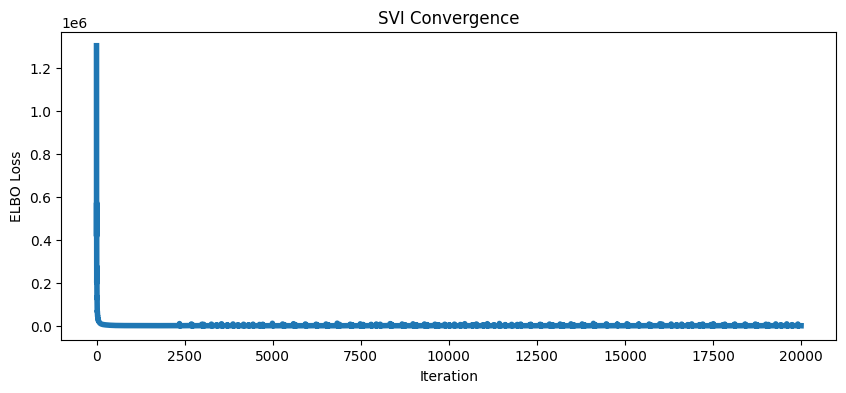

In [60]:
# Run SVI
if RUN_SVI:
    svi_result = run_svi(
        model=bayesian_opinf_model,
        rng_key=rng_key,
        time_eval=time_eval,
        gamma=GAMMA,
        gamma2=GAMMA2,
        num_steps=20000,
        # num_steps=100000,
        learning_rate=1e-1,
        # learning_rate=1e-5,
        verbose=VERBOSE,
        guide=GUIDE
    )
    samples = svi_result.samples
    
    # Extract operator for potential MCMC initialization
    # AutoDelta stores as 'O_auto_loc', MCMC stores as 'O'
    O_key = next((k for k in samples.keys() if 'O' in k and 'ode' not in k.lower()), None)
    if O_key:
        svi_O = samples[O_key]
        # Get point estimate (mean over samples or first sample)
        svi_O_init = svi_O.mean(axis=0) if svi_O.ndim > 2 else svi_O[0]
        print(f"SVI operator extracted from key '{O_key}', shape: {svi_O_init.shape}")
    else:
        svi_O_init = None
        print("Warning: Could not extract O from SVI samples")
    
    # Plot loss
    plt.figure(figsize=(10, 4))
    plt.plot(svi_result.losses, lw=4)
    plt.xlabel('Iteration')
    plt.ylabel('ELBO Loss')
    plt.title('SVI Convergence')
    plt.show()

### 5a. SVI Results

In [61]:
import importlib, fitz_plotter
importlib.reload(fitz_plotter)
from fitz_plotter import FitzPlotter

def _evaluate_and_plot(stage_samples, stage_name):
    """Generate predictions and plots for a given inference stage."""
    Os_stage, Xs_stage, rom_solves_stage = generate_rom_predictions(
        samples=stage_samples, rom=rom,
        snapshots_compressed=snapshots_comp_sampled,
        time_eval=time_domain_eval_prediction,
        num_modes=NUM_MODES, num_pulls=200,
        input_func=input_func,
        data_scaler=data_scaler if USE_SCALED_DATA else None,
        ivp_method=IVP_METHOD,
    )
    print(f"[{stage_name}] Operator samples: {len(Os_stage)}, "
          f"Stable solves: {len(rom_solves_stage)}")

    # Operator posterior summary
    O_mean_stage = Os_stage.mean(axis=0)
    O_std_stage = Os_stage.std(axis=0)
    print(f"\n{stage_name} Posterior mean (first row): {O_mean_stage[0, :5]}")
    print(f"{stage_name} Posterior std  (first row): {O_std_stage[0, :5]}")

    # Get latent state samples and inverse-transform if scaled
    latent_state_samples = []
    for i in range(NUM_MODES):
        key_multi = f'X0_{i}'
        key_legacy = f'X{i}'
        key = key_multi if key_multi in stage_samples else key_legacy
        if key in stage_samples:
            Xi = stage_samples[key]
            if USE_SCALED_DATA and data_scaler is not None:
                Xi = np.array(Xi) * data_scaler.stds_[i, 0] + data_scaler.means_[i, 0]
            latent_state_samples.append(Xi)
        else:
            latent_state_samples.append(np.tile(snapshots_comp_sampled[i], (len(Os_stage), 1)))

    # State reconstruction using FitzPlotter
    plotter_stage = FitzPlotter(
        numPODmodes=NUM_MODES,
        time_domain_training=time_sampled,
        time_domain_prediction=time_domain_full,
        time_domain_eval_training=time_domain_eval_training,
        time_domain_eval_prediction=time_domain_eval_prediction,
        snapshots_training=snapshots_comp_sampled,
        snapshots_prediction=full_states_compressed,
    )

    try:
        # Single-column view
        fig_rom = plotter_stage.operator_plot(
            q0=snapshots_comp_sampled[:, 0],
            operator_samples=Os_stage,
            latent_state_samples=latent_state_samples,
            rom=rom,
            input_func=input_func,
            figsize=(10, 2.5 * NUM_MODES),
            max_num_samples=200,
            plot_single=True,
            training_span=TRAINING_SPAN,
        )
        plt.suptitle(f'ROM Predictions ({stage_name})', fontsize=14)
        plt.show()
    except Exception as e:
        fig_rom = None
        print(f"Failed to generate a plot due to: {e}")

    # Full-order prediction error
    rom_solves_pred = []
    q0 = snapshots_comp_sampled[:, 0]
    for O in Os_stage:
        rom.model._extract_operators(O)
        try:
            rom.model.predict(state0=q0, t=time_domain_eval_prediction, input_func=input_func, method=IVP_METHOD)
            if rom.model.predict_result_.y.shape[1] == len(time_domain_eval_prediction):
                rom_solves_pred.append(rom.model.predict_result_.y)
        except Exception:
            pass
    rom_solves_pred = np.array(rom_solves_pred)
    print(f"Stable ROM solves on prediction domain: {len(rom_solves_pred)}")

    if len(rom_solves_pred) > 0:
        fig, axes = plot_full_order_error(
            rom_solves=rom_solves_pred,
            basis=basis,
            true_states=true_states,
            time_domain_full=time_domain_full,
            time_domain_eval=time_domain_eval_prediction,
            training_span=TRAINING_SPAN,
            error_type='relative',
            figsize=(12, 10),
        )
        plt.suptitle(f'Full-Order Error ({stage_name})', fontsize=14)
        fig_error = fig
        plt.show()
    else:
        fig_error = None

    return Os_stage, rom_solves_stage, fig_rom, fig_error

[SVI] Operator samples: 200, Stable solves: 200

SVI Posterior mean (first row): [ 55.90331   -15.612369  -19.476315  -46.6036      0.6026307]
SVI Posterior std  (first row): [4.1961670e-05 1.5258789e-05 1.5258789e-05 5.7220459e-05 1.1920929e-07]
(200, 3, 14) (1000, 3, 250)
(200, 3, 150) (200, 3, 150)


<Figure size 640x480 with 0 Axes>

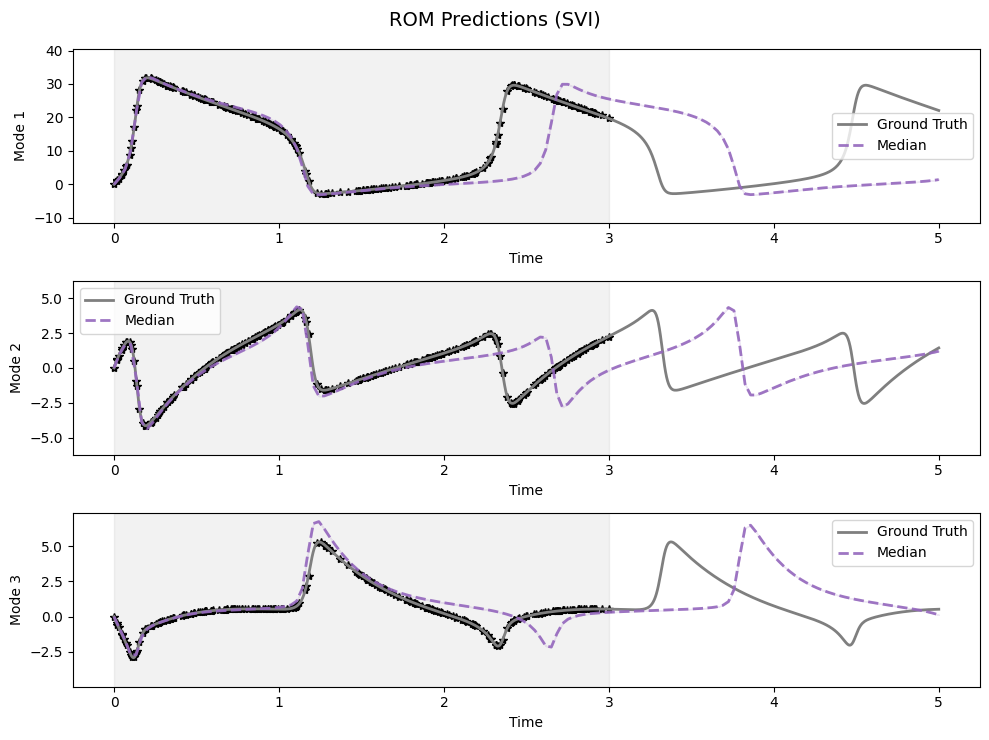

Stable ROM solves on prediction domain: 200


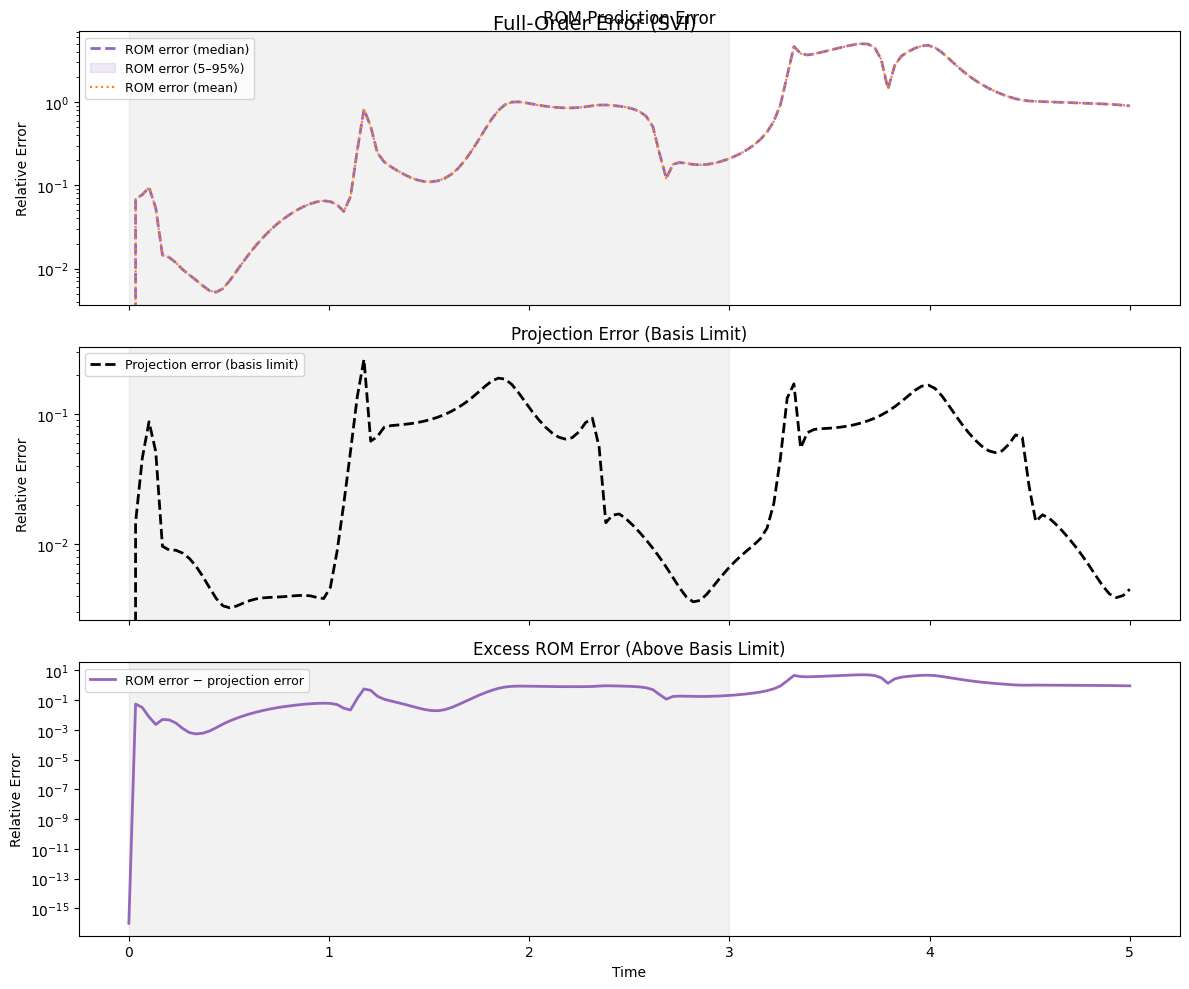

In [62]:
# === SVI Results ===
svi_start_time = time.time()

if RUN_SVI:
    svi_Os, svi_rom_solves, svi_fig_rom, svi_fig_err = _evaluate_and_plot(svi_result.samples, "SVI")

total_plot_time += time.time() - svi_start_time

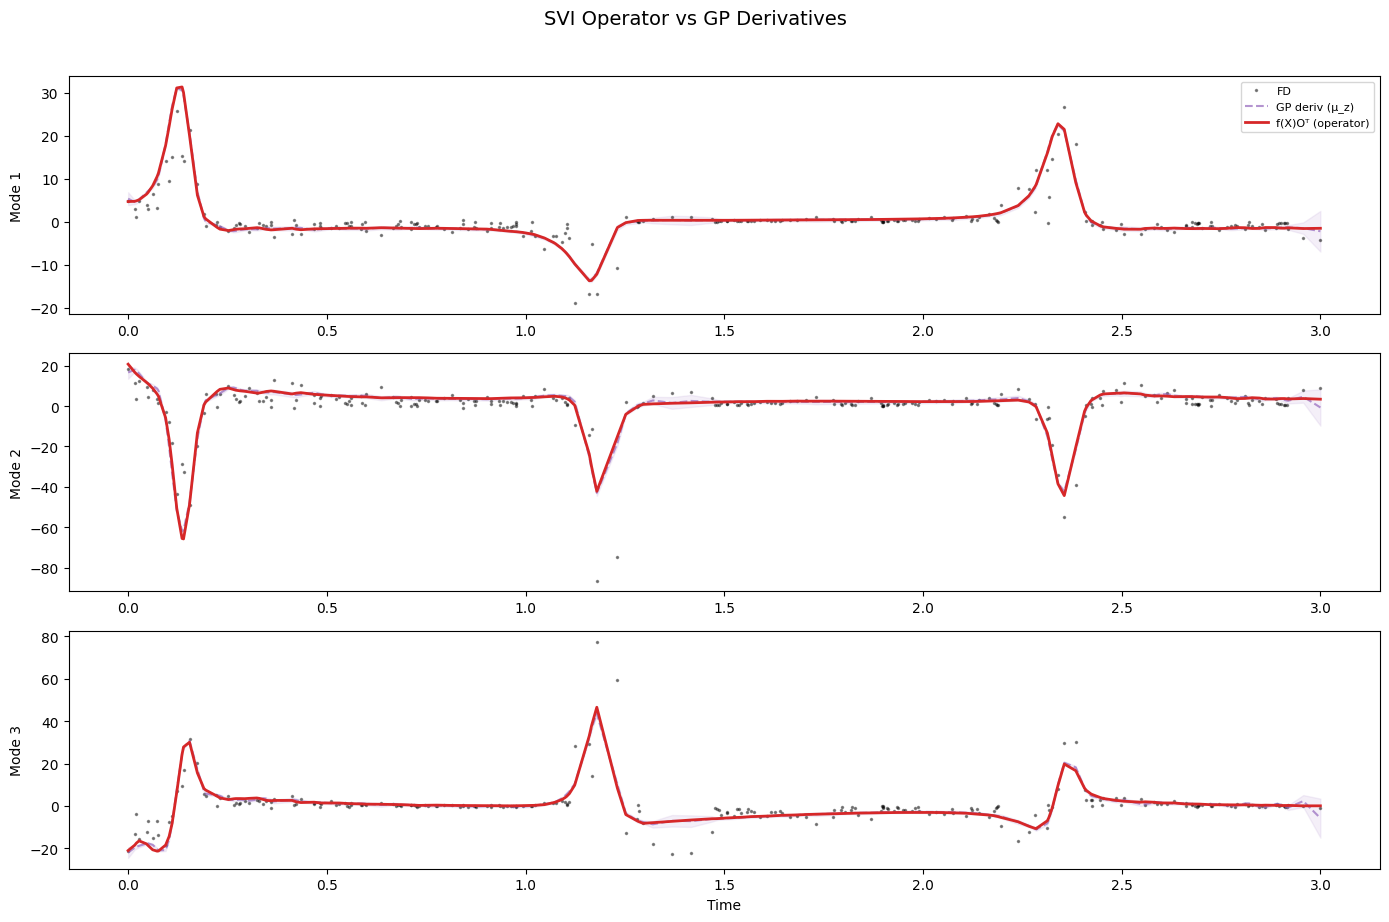

In [63]:
# Operator derivative fit diagnostic (SVI)
try:
    _O_mean = svi_Os.mean(axis=0)
    plot_operator_derivative_fit(
        operator=_O_mean,
        rom=rom,
        Xs_means=Xs_means,
        time_eval=time_eval,
        Ls=Ls, Vs=Vs,
        time_train=time_sampled,
        snapshots=training_data,
        Ns=Ns,
        inputs_eval=inputs_eval,
        data_scaler=data_scaler if USE_SCALED_DATA else None,
        title="SVI Operator vs GP Derivatives",
    )
    plt.show()
except Exception as e:
    print(f"SVI derivative fit plot failed: {e}")


In [64]:
# Run MCMC (optional, more expensive)
if RUN_MCMC:
    # Initialize from SVI if requested and available
    init_values = None
    if USE_SVI_FOR_MCMC_INIT and RUN_SVI and 'svi_O_init' in dir() and svi_O_init is not None:
        init_values = {"O": svi_O_init}
        print(f"Initializing MCMC from SVI result (shape: {svi_O_init.shape})")
    else:
        print("MCMC will find its own starting point via NUTS adaptation")

    # Build shifted model or reuse SVI model
    if USE_SHIFTED_PRIOR_FOR_MCMC and RUN_SVI and 'svi_Os' in dir():
        mcmc_model = build_bayesian_opinf_model(
            prior_operator=jnp.zeros_like(prior_operator),
            rom=rom,
            Ls_means=Ls,
            Vs_means=Vs,
            time_domain_sampled=time_sampled,
            snapshots=training_data,
            Xs_means=Xs_means,
            Ns_means=Ns,
            inputs_eval=inputs_eval,
            data_scaler=data_scaler if USE_SCALED_DATA else None,
            reparam="shifted",
            svi_O_mean=svi_Os.mean(axis=0),
            svi_O_std=jnp.ones_like(svi_Os.mean(axis=0))*GAMMA3,
            relative_gamma=True,
    relative_gamma2=RELATIVE_GAMMA2,
        )
        print("Built shifted model: prior re-centered on SVI posterior")
    else:
        mcmc_model = bayesian_opinf_model
        print("Using original model for MCMC")

    mcmc_result = run_mcmc(
        model=mcmc_model,
        rng_key=jax.random.PRNGKey(1),
        time_eval=time_eval,
        init_values=init_values,
        gamma=GAMMA3 if GAMMA3 else GAMMA,
        gamma2=GAMMA4 if GAMMA4 else GAMMA2,
        num_warmup=150 * 2,
        num_samples=200 * 2,
        num_chains=2,
        verbose=VERBOSE,
        target_accept=0.7,
    )
    samples = mcmc_result.samples

Initializing MCMC from SVI result (shape: (3, 14))
Built shifted model: prior re-centered on SVI posterior
Running MCMC (2 chains, 300 warmup, 400 samples)...


sample: 100%|██████████| 700/700 [01:33<00:00,  7.47it/s, 2047 steps of size 2.09e-03. acc. prob=0.91]


✅ MCMC complete! 800 samples collected.


In [65]:
# End time of the algorithm

end_time = time.time()
algo_time = end_time - start_time - total_plot_time

print(f"Total wall time: {end_time - start_time:.1f}s")
print(f"Plot time excluded: {total_plot_time:.1f}s")
print(f"Algorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")

Total wall time: 277.6s
Plot time excluded: 24.6s
Algorithm runtime: 253.1s (4.2min)


### 5b. MCMC Results

[MCMC] Operator samples: 200, Stable solves: 200

MCMC Posterior mean (first row): [ 56.17759   -15.9262905 -19.450115  -46.922577    0.6148745]
MCMC Posterior std  (first row): [1.5265993  1.812798   2.217846   1.7186264  0.07295492]
(200, 3, 14) (800, 3, 250)
(200, 3, 150) (200, 3, 150)


<Figure size 640x480 with 0 Axes>

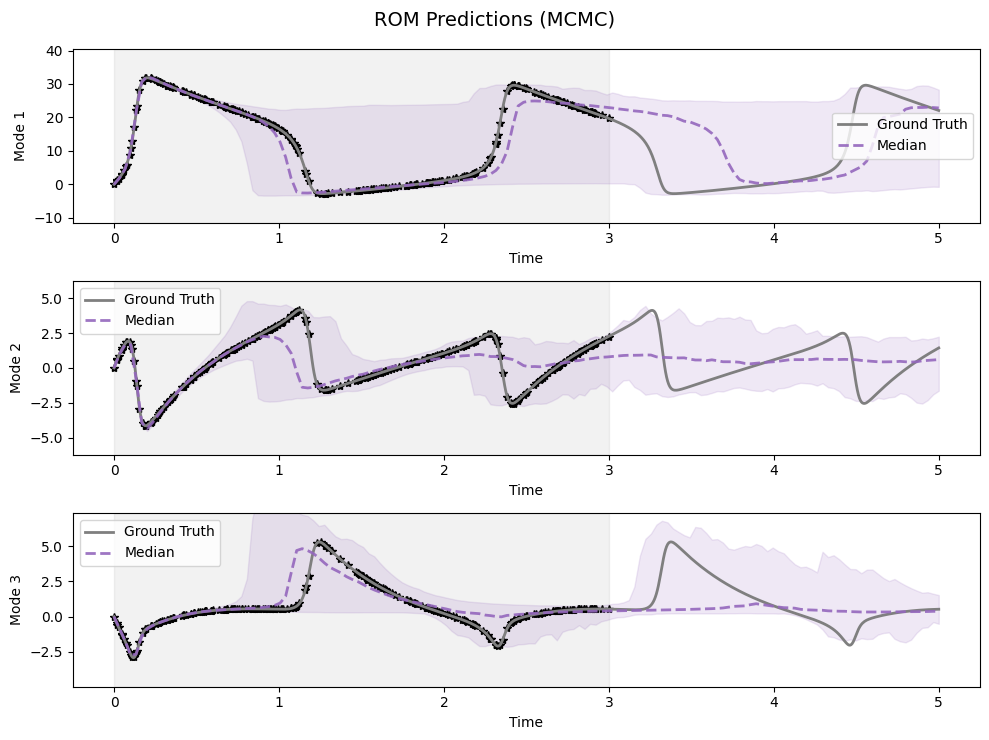

Stable ROM solves on prediction domain: 200


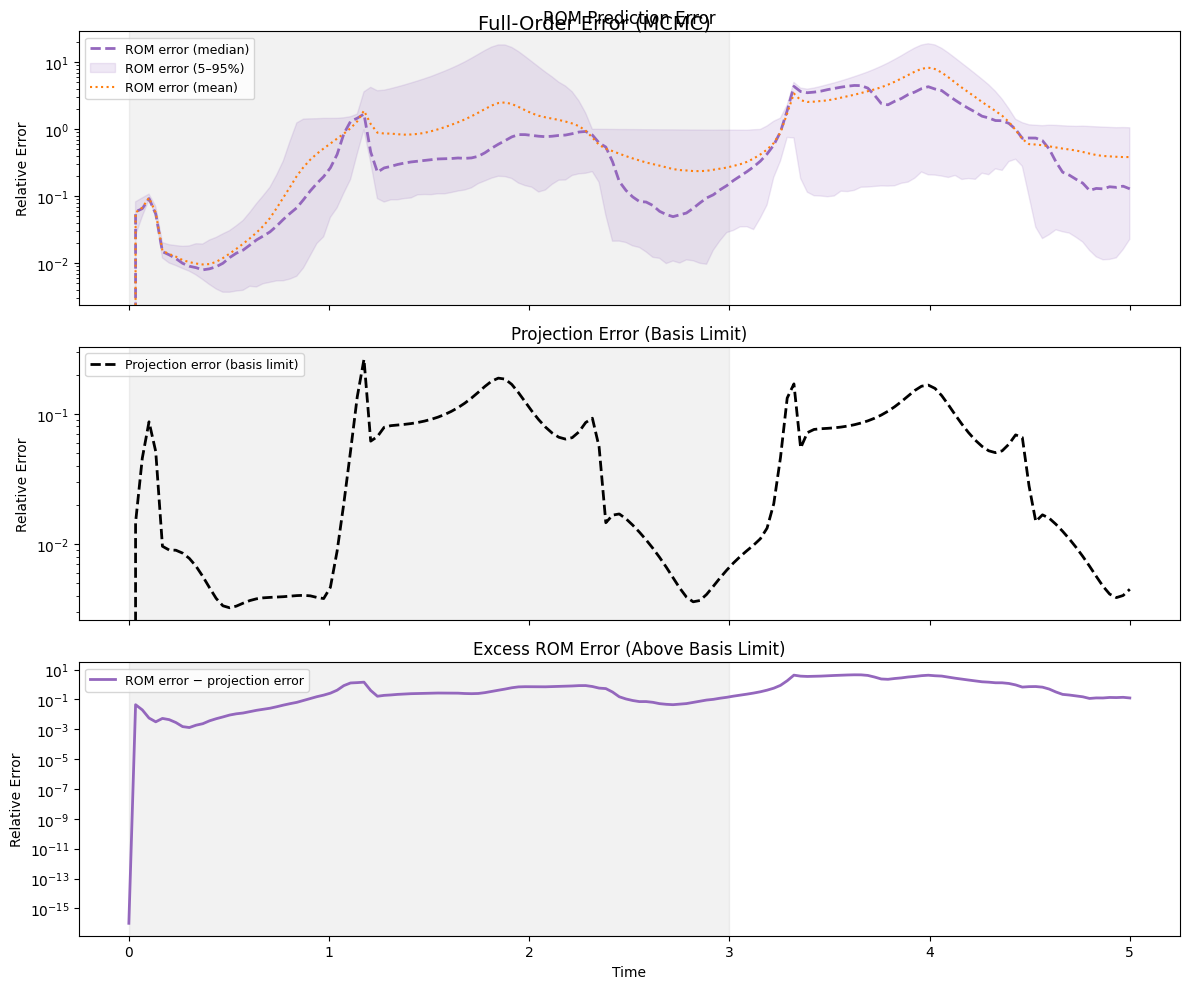

In [66]:
# === MCMC Results ===
_plot_t0 = time.time()
if RUN_MCMC:
    mcmc_Os, mcmc_rom_solves, mcmc_fig_rom, mcmc_fig_err = _evaluate_and_plot(mcmc_result.samples, "MCMC")
    if SAVE_PAPER_FIGURES:
        save_paper_figure(mcmc_fig_rom, f"fn_{PAPER_SCENARIO}_fb", PAPER_FIGURES_DIR)
        if mcmc_fig_err is not None:
            save_paper_figure(mcmc_fig_err, f"fn_{PAPER_SCENARIO}_fb_error", PAPER_FIGURES_DIR)
total_plot_time += time.time() - _plot_t0

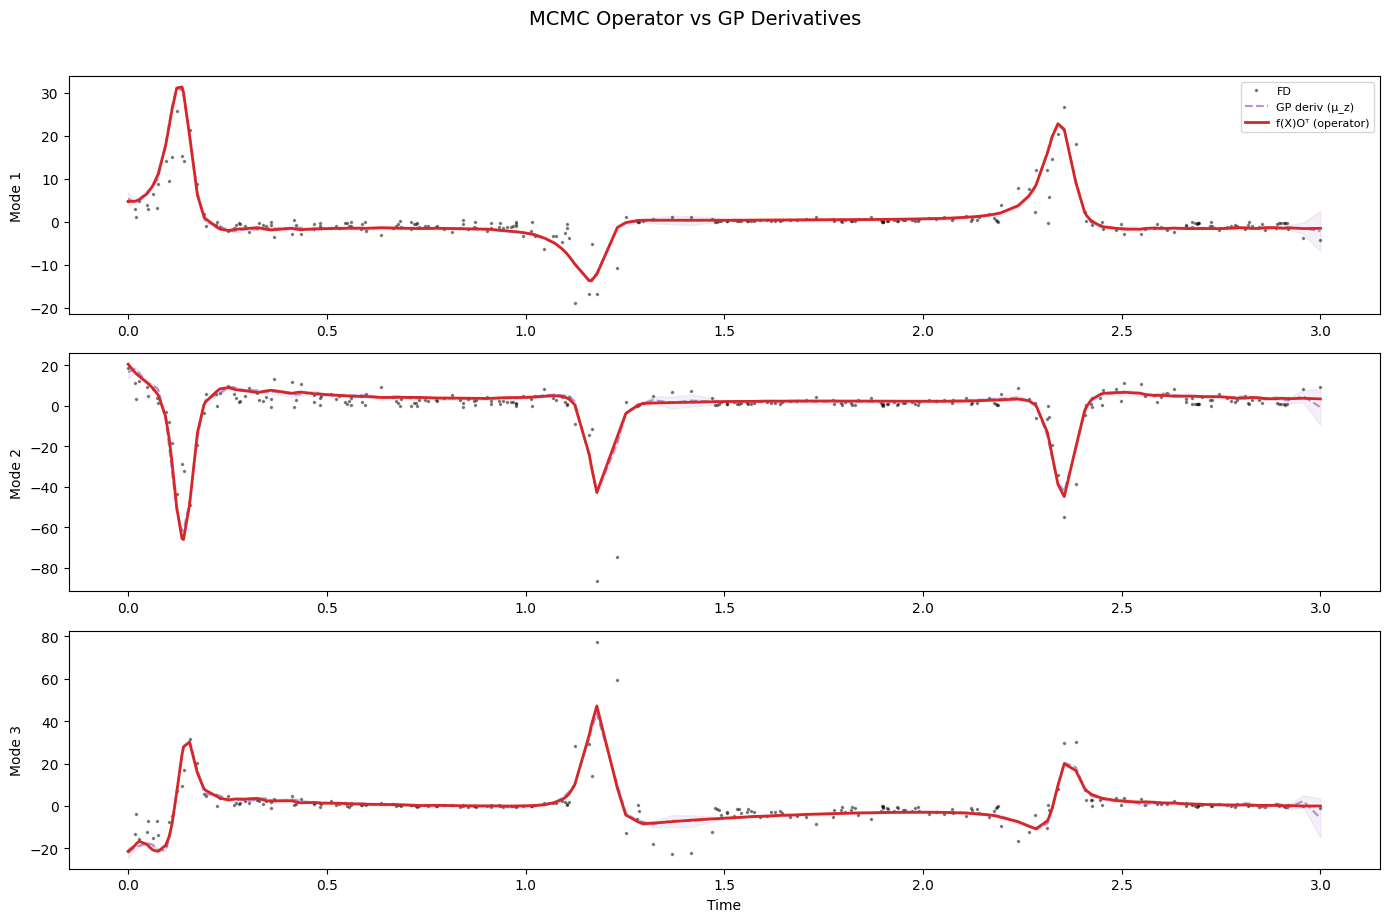

In [67]:
# Operator derivative fit diagnostic (MCMC)
if RUN_MCMC:
    try:
        _O_mean = mcmc_Os.mean(axis=0)
        plot_operator_derivative_fit(
            operator=_O_mean,
            rom=rom,
            Xs_means=Xs_means,
            time_eval=time_eval,
            Ls=Ls, Vs=Vs,
            time_train=time_sampled,
            snapshots=training_data,
            Ns=Ns,
            inputs_eval=inputs_eval,
            data_scaler=data_scaler if USE_SCALED_DATA else None,
            title="MCMC Operator vs GP Derivatives",
        )
        plt.show()
    except Exception as e:
        print(f"MCMC derivative fit plot failed: {e}")


## 6. Summary

In [68]:
# Summary
print("=" * 50)
print("EXPERIMENT SUMMARY: FitzHugh-Nagumo")
print("=" * 50)
print(f"Operators: {OPERATORS}")
print(f"Modes: {NUM_MODES}")
print(f"Training span: [{TRAINING_SPAN[0]}, {TRAINING_SPAN[1]}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]}, {PREDICTION_SPAN[1]}]")
print(f"Scaling: {'enabled' if USE_SCALED_DATA else 'disabled'}")
print(f"Prior regularization: {result.best_reg:.1e}")
print(f"Prior error: {result.best_error:.4%}")
print(f"Gamma (operator): {GAMMA}")
print(f"Gamma2 (ODE): {GAMMA2}")
print(f"Guide: {GUIDE.__name__}")
if RUN_SVI:
    print(f"\nSVI: {len(svi_Os)} operator samples, {len(svi_rom_solves)} stable solves")
if RUN_MCMC:
    print(f"MCMC: {len(mcmc_Os)} operator samples, {len(mcmc_rom_solves)} stable solves")

EXPERIMENT SUMMARY: FitzHugh-Nagumo
Operators: cAHBN
Modes: 3
Training span: [0, 3.0]
Prediction span: [0, 5.0]
Scaling: enabled
Prior regularization: 9.5e+00
Prior error: 27.3751%
Gamma (operator): 1.0
Gamma2 (ODE): 1.0
Guide: AutoDelta

SVI: 200 operator samples, 200 stable solves
MCMC: 200 operator samples, 200 stable solves


## 7. Bayesian Model Diagnostics

Run post-inference diagnostics to check for common pitfalls:
- **Posterior correlation** — highly correlated parameters suggest redundancy or non-identifiability
- **Effective sample size (ESS)** — low ESS means samples are highly autocorrelated
- **Prior-posterior overlap** — checks if data is actually informing the posterior
- **Trace plots** — visual check for mixing and stationarity
- **Divergences & R-hat** — MCMC-specific convergence checks (when applicable)

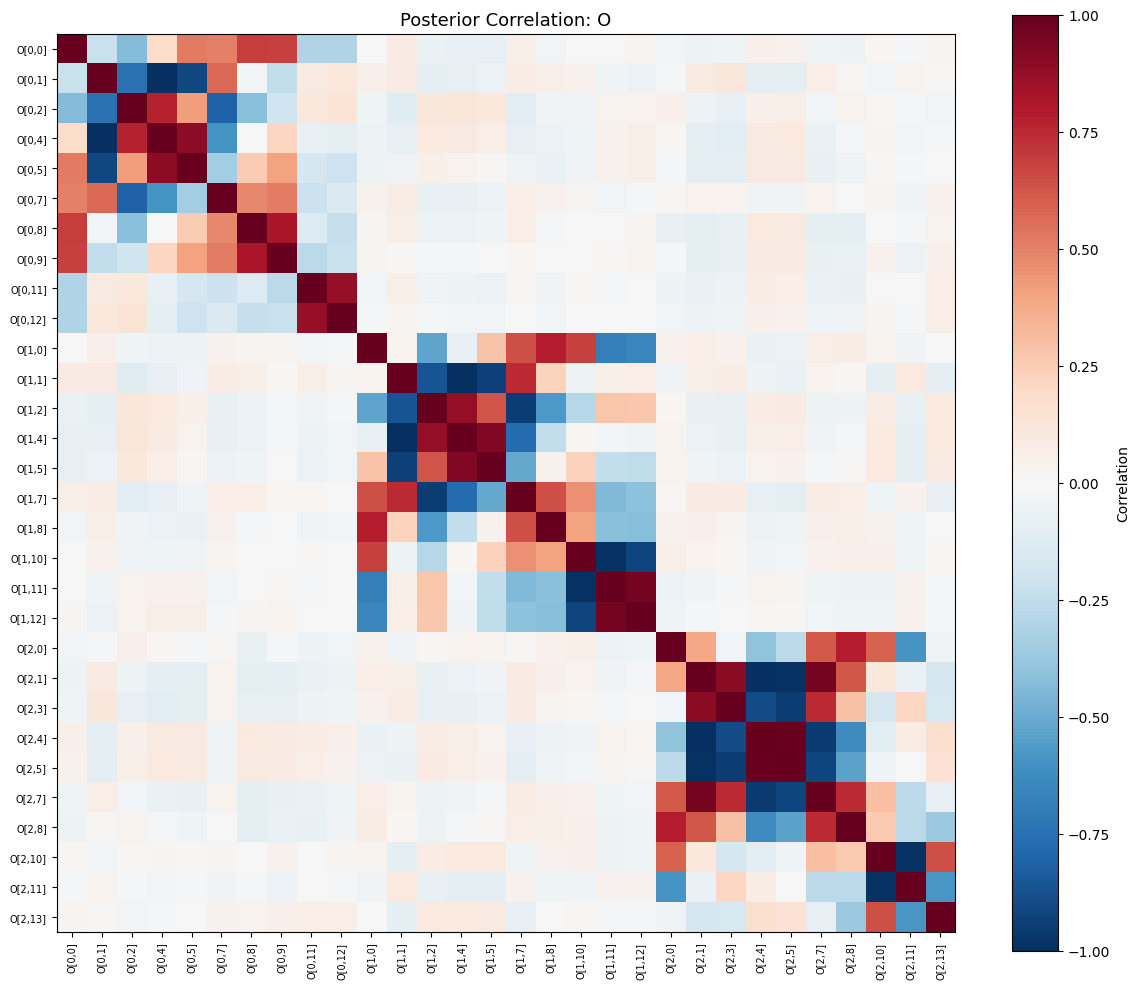

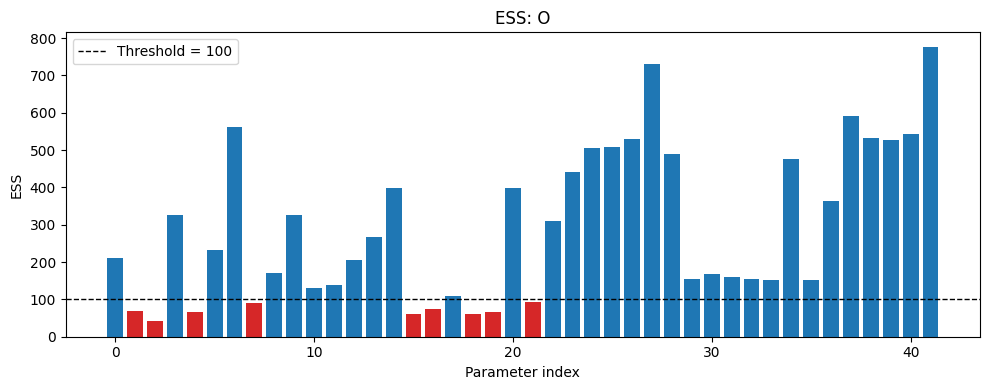

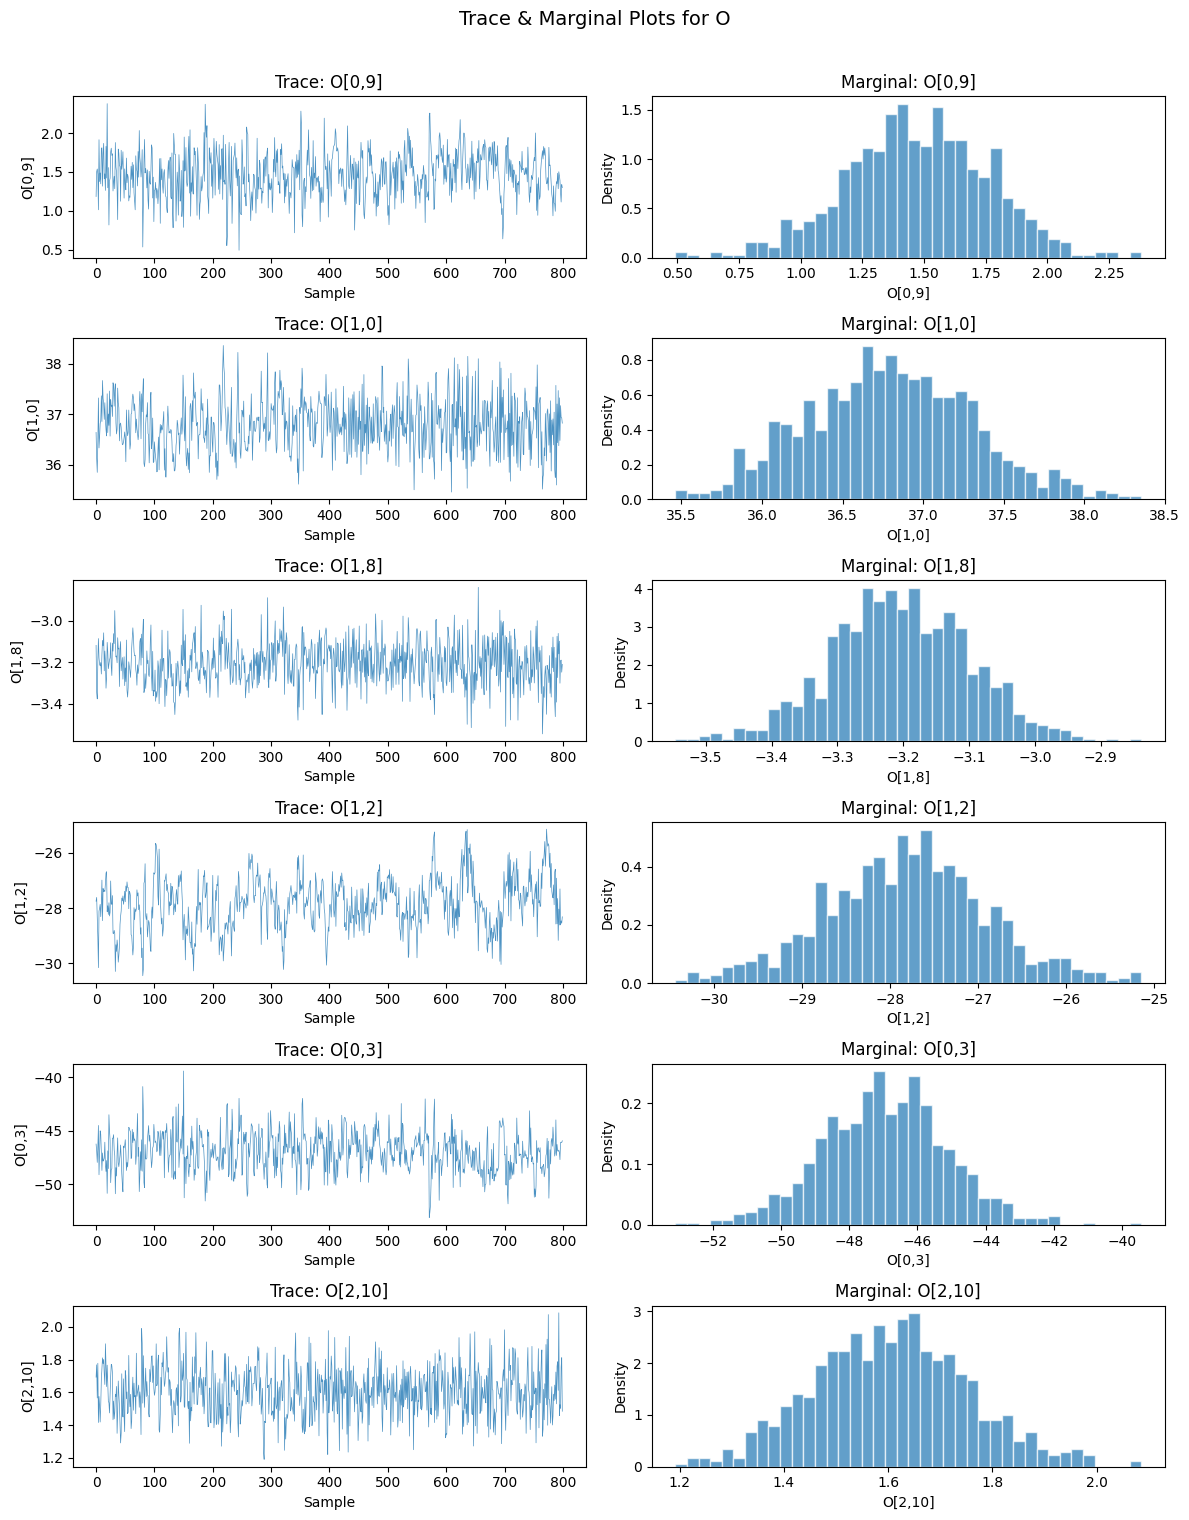

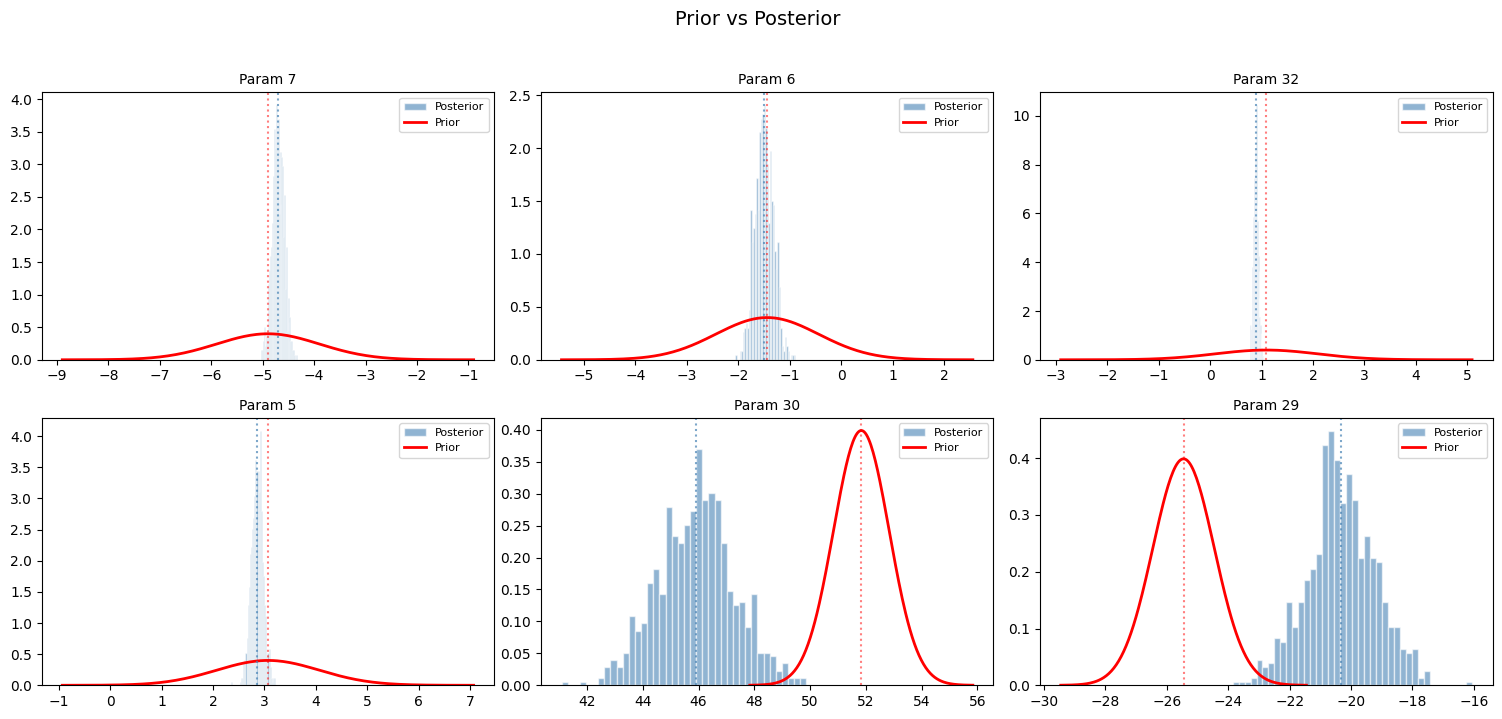

  BAYESIAN MODEL DIAGNOSTIC REPORT

--- Posterior Correlation ---
  24 highly correlated pairs (|r| > 0.9):
    O[2,1] <-> O[2,4]: r = -1.000
    O[1,1] <-> O[1,4]: r = -0.999
    O[0,1] <-> O[0,4]: r = -0.999
    O[1,10] <-> O[1,11]: r = -0.990
    O[2,1] <-> O[2,5]: r = -0.989
    O[2,4] <-> O[2,5]: r = +0.987
    O[2,10] <-> O[2,11]: r = -0.987
    O[2,2] <-> O[2,7]: r = -0.987
    O[2,2] <-> O[2,4]: r = +0.982
    O[2,1] <-> O[2,2]: r = -0.979
    ... and 14 more

--- Effective Sample Size (ESS) ---
  Min ESS:  43.1
  Mean ESS: 294.3
  Max ESS:  776.5
    O[0,2]: ESS = 43.1
    O[1,1]: ESS = 59.8
    O[1,4]: ESS = 59.8
    O[0,4]: ESS = 66.1
    O[1,5]: ESS = 66.3

--- MCMC Divergences ---
  Divergent transitions: 0
  Fraction: 0.00%

--- Prior-Posterior Overlap ---
  O[0,2]: overlap = 11.85% [OK]
  O[2,13]: overlap = 6.44% [CHECK]
  O[1,8]: overlap = 21.52% [OK]
  O[1,13]: overlap = 7.19% [CHECK]
  O[0,8]: overlap = 54.82% [OK]

--- Summary Warnings ---
  1. Found 24 highly correl

In [69]:
# Use MCMC samples if available, otherwise SVI
diag_samples = mcmc_result.samples if RUN_MCMC else svi_result.samples

# Run full diagnostic suite
diag_report = run_diagnostics(
    samples=diag_samples,
    param_name="O",
    prior_mean=prior_operator,
    prior_std=GAMMA,
    mcmc_result=mcmc_result if RUN_MCMC else None,
    samples_by_chain=None,
    correlation_threshold=0.9,
    ess_threshold=100,
    verbose=VERBOSE,
    plot=True,
)

  STABILITY DIAGNOSTIC REPORT

--- Operator Stability ---
  Prior operator:     STABLE
  Posterior MAP/mean: STABLE

--- ELBO Convergence ---
  Status: converged  (final slope = 1.11e+00)

--- Prior → Posterior Shift ---
  Mode 0: ‖ΔO‖ = 6.8387
  Mode 1: ‖ΔO‖ = 10.7616
  Mode 2: ‖ΔO‖ = 8.3864
  Per-block relative shift (‖Δblock‖/‖prior_block‖):
    c: 0.0111
    A: 0.1748
    H: 0.0868
    B: 0.1849
    N: 0.1154

--- Linear Operator (A) Eigenvalues ---
  Prior  max Re(λ): +15.619108  (unstable!)
  Post.  max Re(λ): +12.714412  (unstable!)

--- Perturbation Sensitivity ---
  Perturb c: ████████████████████ 100% stable
  Perturb A: ██████████████████░░ 91% stable
  Perturb H: ██████████████████░░ 91% stable
  Perturb B: ████████████████████ 100% stable
  Perturb N: ████████████████████ 100% stable

--- ⚠  Warnings ---
  • Posterior A has eigenvalue with Re(λ)=+12.7144 — linear dynamics are unstable.


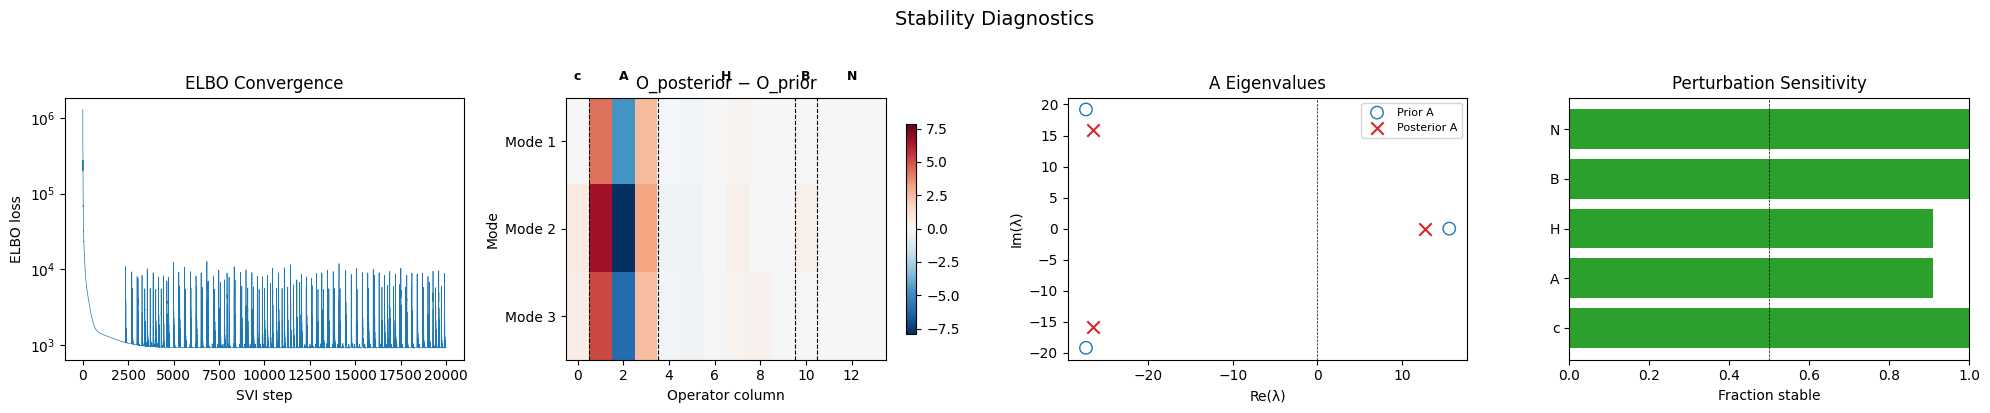

In [70]:
# Stability diagnostics: MAP stability, ELBO convergence, eigenvalues, perturbation sensitivity
posterior_O = (mcmc_Os if RUN_MCMC else svi_Os).mean(axis=0)
stability_report = diagnose_stability(
    posterior_operator=posterior_O,
    prior_operator=prior_operator,
    rom=rom,
    snapshots_compressed=snapshots_comp_sampled,
    time_eval=time_domain_eval_prediction,
    operators=OPERATORS,
    input_func=input_func,
    input_dim=1,
    losses=svi_result.losses if RUN_SVI else None,
)
